# Домашнее Задание
Выполнил Вершинин Данил, Б9122-01.03.02мкт


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import seaborn as sns

## Logistic Regression (Своими Силами)

1. Дописать код градиентного спуска ниже
2. Поиграться с датасетом, предложеннным выше
3. Построить свою версию Логистической регресии (на каком-то одном числовом факторе без пропусков), сравнить результаты с LogisticRegression из SKlearn (Оценить метрики - ROC AUC, подобрать порог и Построить Confusion Matrix, а так же производные метрики от неё )
4. Заполнить пропуски, обработать категориальные переменные, обучить свою версию модели и Logistic Regression, сравнить качество между ними (см п.3) + с моделями из п.3 (как добавление бОльшего количества факторов влияет на качество модели)
5. *Поиграться с нормировкой данных (sklearn.model_selection.StandardScaler) оценить эффект на веса модели и её качество
6. Разбить факторы на Клиентские/Продуктовые/Кредитная История и построить по одной модели на каждом факторе. Затем построить мета-модель (интегральная модель) на трёх факторах - скорах метамоделях (дрейверы) - Сравнить результаты по каждому из драйеров + интегральной модели с одной моделью на всём факторном прстранстве.
7. *Привести график качества (ROC AUC) модели на фиксированной тренировочной выборке в зависимости от количества наблюдений, которые используются при обучении (train выборка). Например: 100, 500, 1000 и тд.

*- задания со звёздочкой, не обязательно, но довольно интересные

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def logloss(y, p):
    return -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()

In [ ]:
!gdown 1nCHCT5XWio5fSN0mYNwRbEzTGL_sIcN4

Downloading...
From: https://drive.google.com/uc?id=1nCHCT5XWio5fSN0mYNwRbEzTGL_sIcN4
To: /content/loan_data.csv
100% 3.61M/3.61M [00:00<00:00, 38.9MB/s]


In [ ]:
df = pd.read_csv("loan_data.csv")

In [ ]:
TARGET = "loan_status"

Наиболее коррелирующая фича с TARGET: 'loan_percent_income' (коэффициент корреляции = 0.385)


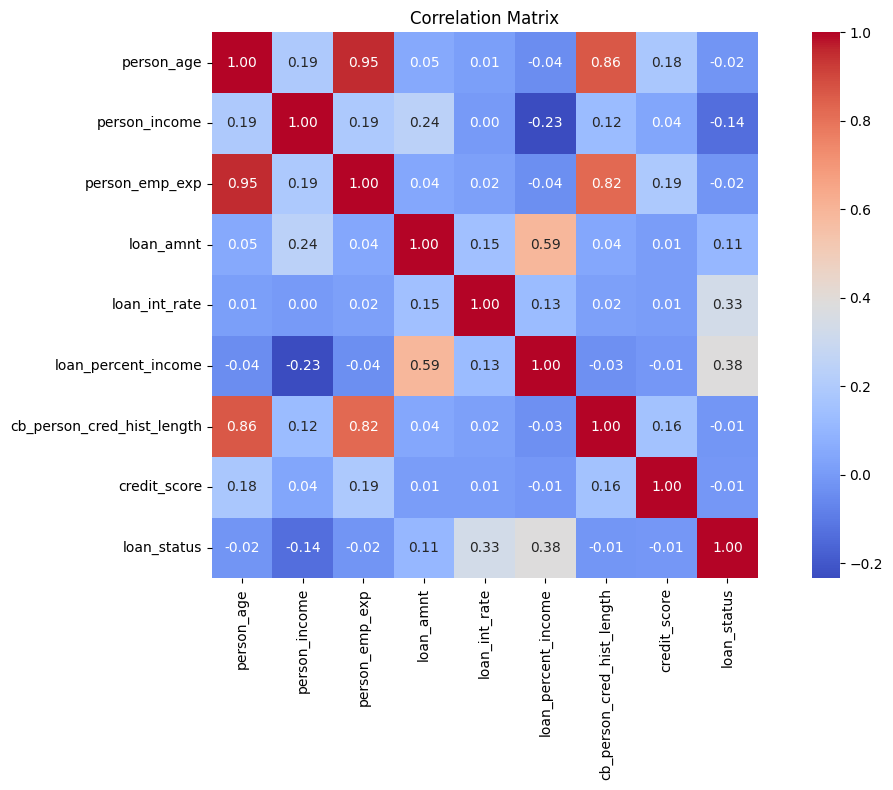

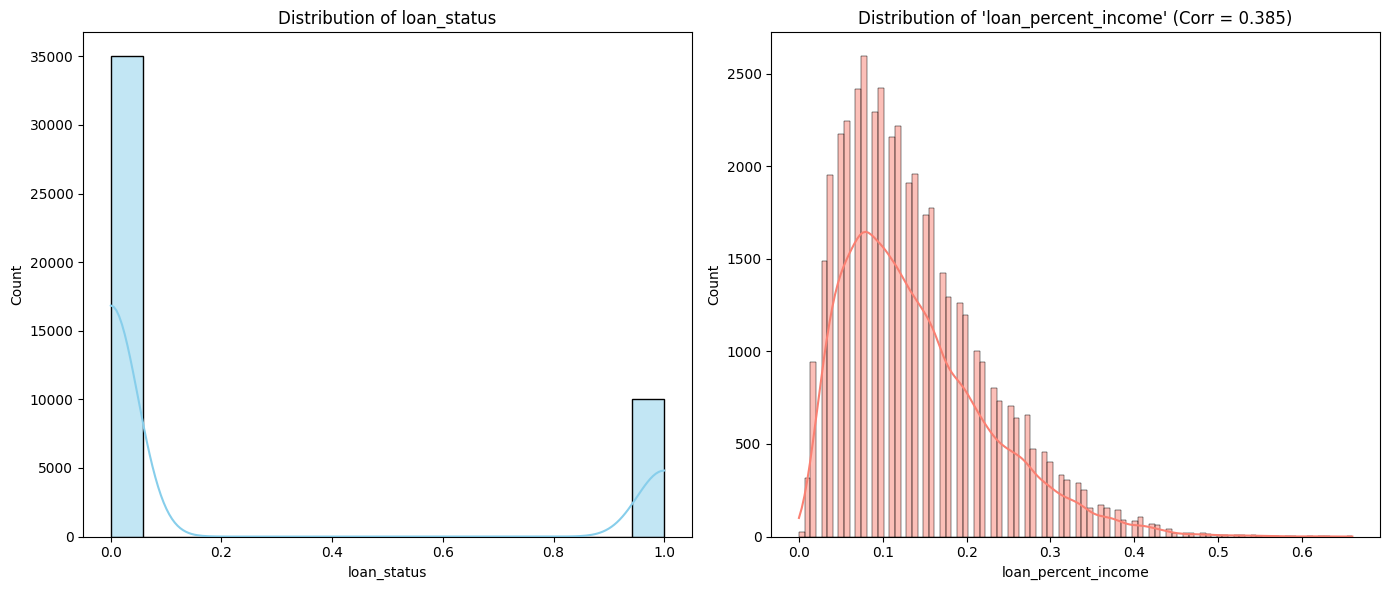

In [ ]:
correlation_matrix = df.corr(numeric_only=True)

target_correlations = correlation_matrix[TARGET].drop(TARGET)
top_feature = target_correlations.abs().idxmax()
top_corr_value = target_correlations[top_feature]

print(
    f"Наиболее коррелирующая фича с TARGET: '{top_feature}' (коэффициент корреляции = {top_corr_value:.3f})"
)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[TARGET], kde=True, color="skyblue")
plt.title(f"Distribution of {TARGET}")
plt.xlabel(TARGET)

plt.subplot(1, 2, 2)
sns.histplot(df[top_feature], kde=True, color="salmon")
plt.title(f"Distribution of '{top_feature}' (Corr = {top_corr_value:.3f})")
plt.xlabel(top_feature)

plt.tight_layout()
plt.show()

### базовая модель с одним параметром

In [ ]:
# Реализуем собственный класс логистической регрессии
class MyLogisticRegression:
    def __init__(self, lr=1e-4, bias=True):
        self.bias = bool(bias)
        self.weights = None
        self.lr = lr

    def preproc_x(self, X):
        # Добавляем bias если требуется
        return np.hstack([np.ones((X.shape[0], 1)), X]) if self.bias else X

    def fit(self, X, y, c_epoch=1000):
        # Инициализируем веса
        self.weights = np.ones(X.shape[1] + self.bias)

        self.X = self.preproc_x(X)
        self.y = y

        # Стохастический градиентный спуск
        # Итерируемся по количеству эпох
        for i in range(c_epoch):
            # Перешмешиваем наблюдения случайным образом
            ids = list(range(self.X.shape[0]))
            np.random.shuffle(ids)

            # итерируемся по наблюдениям
            for j in ids:
                p = sigmoid(np.dot(self.X[j], self.weights))
                # !TODO: Реализовать самостоятельно
                self.weights -= self.lr * (p - self.y.iloc[j]) * self.X[j]
            probs = sigmoid(np.dot(self.X, self.weights))
            print(i, ":", logloss(self.y, probs))

    def predict_proba(self, X):
        X = self.preproc_x(X)
        return sigmoid((X @ self.weights) * 1)

    def predict(self, X):
        X = self.preproc_x(X)
        preds = (sigmoid((X @ self.weights) * 1) > 0.5).astype(int)
        return preds

In [ ]:
# Считываем скачанный csv файл
df = pd.read_csv("loan_data.csv")

In [ ]:
from numpy import random

# зашумим часть данных для дальнейшего интереса :-)

# Зашумим случаный 1000 возрастов (может быть меньше с учетом коллизий индексов)
# Это даст нам случайное распределение пустот
df.loc[random.choice(range(df.shape[0]), 1000), "person_age"] = np.nan

# Уберём значительную часть доходов у людей, которые хотят взять кредит на образование
# Это зашумление нам даст неслучайное смещение
df.loc[df[df["loan_intent"] == "EDUCATION"].sample(3000).index, "person_income"] = (
    np.nan
)

In [ ]:
# Разбить на train и test выборки
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3)
features = ["credit_score"]

X_train = train[features]
y_train = train[TARGET]

X_test = test[features]
y_test = test[TARGET]

In [ ]:
# Обучить свою версию и sklearn'овскую версию Логистической Регрессии

my_lr = MyLogisticRegression()
sk_lr = LogisticRegression()

my_lr.fit(X_train, y_train, 48)
sk_lr.fit(X_train, y_train)

0 : 1.7072530303182756
1 : 4.276196202696862
2 : 3.033653934618781
3 : 2.8574142556059217
4 : 4.265226459716937
5 : 20.195166827974006
6 : 9.767584840581689
7 : 3.463160356577263
8 : 2.864689472487632
9 : 5.362085824957838
10 : 4.354098604058079
11 : 5.9116552652371155


<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()


12 : inf
13 : 5.901195227664341
14 : 3.451065635823488
15 : 5.403318598340842
16 : 5.234336700386759
17 : 2.8713530128103963
18 : 0.8524033874986021
19 : 4.637021895997764
20 : 3.1799807434417446
21 : 5.405626912161659
22 : 5.7885459156461
23 : 1.7289338503152103
24 : 3.1503335069007887
25 : 5.9178303554479195
26 : 5.7731121394242795
27 : 0.7473936019724966
28 : 2.7383262195080733
29 : 4.752901476651121
30 : 7.101158465602012
31 : 6.51591718078585
32 : 2.4163038964929275
33 : 1.1357911373139038
34 : 5.77714114503322
35 : 6.827175398349052


<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()


36 : inf
37 : 15.417557560059436
38 : 6.005487800052177
39 : 5.657508458376034
40 : 3.0226193211596573
41 : 5.0877265411701815
42 : 3.624211753321822
43 : 7.370628333227599
44 : 3.296927601982095
45 : 1.8498357758493447
46 : 2.099379667988396
47 : 5.042818110942105


LogisticRegression()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

Добавим поля предсказаний в датафреймы

In [ ]:
train["my_predict"] = my_lr.predict_proba(X_train)
test["my_predict"] = my_lr.predict_proba(X_test)

In [ ]:
train["sk_predict"] = sk_lr.predict_proba(X_train)[:, 1]
test["sk_predict"] = sk_lr.predict_proba(X_test)[:, 1]

<Axes: >

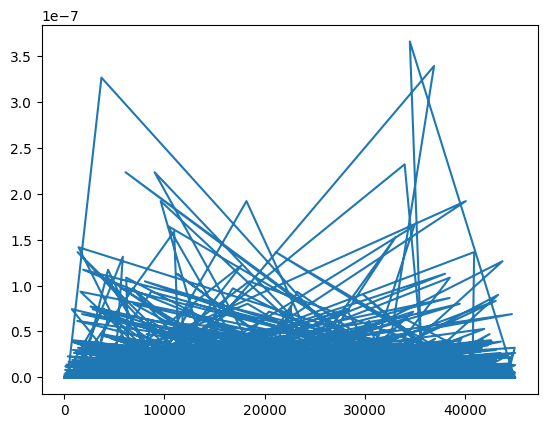

In [ ]:
train["my_predict"].plot()

Построим conf matrixes

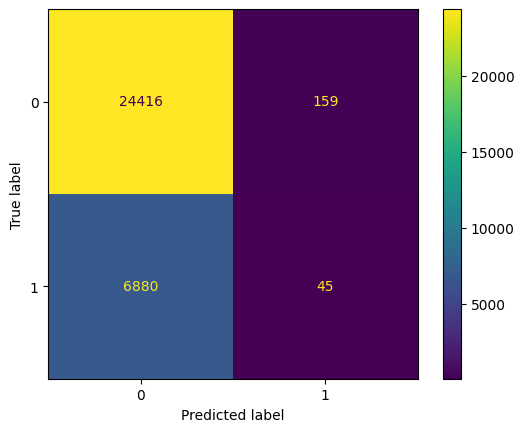

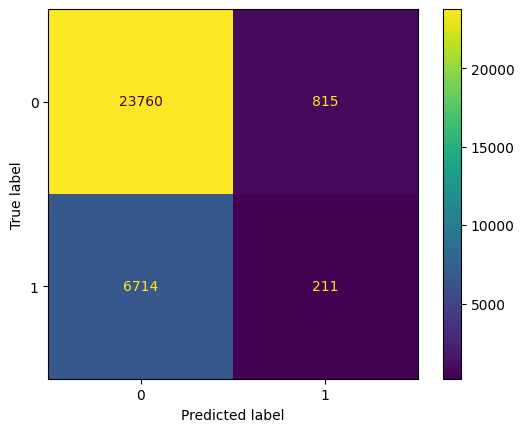

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix(train[TARGET], train["my_predict"] > 0.000000025)
).plot()
ConfusionMatrixDisplay(
    confusion_matrix(train[TARGET], train["sk_predict"] > 0.225)
).plot()

И другие метрики

In [ ]:
accuracy_score(y_train, train["my_predict"] > 0.000000025)

0.7765396825396825

In [ ]:
accuracy_score(y_test, test["my_predict"] > 0.000000025)

0.7685185185185185

In [ ]:
accuracy_score(y_train, train["sk_predict"] > 0.225)

0.760984126984127

In [ ]:
accuracy_score(y_test, test["sk_predict"] > 0.225)

0.7545185185185185

In [ ]:
roc_auc_score(y_test, test["my_predict"] > 0.000000025)

np.float64(0.5005825583435691)

In [ ]:
roc_auc_score(y_test, test["sk_predict"] > 0.225)

np.float64(0.5013768497397204)

In [ ]:
precision_score(y_test, test["my_predict"] > 0.000000025)

0.2549019607843137

In [ ]:
precision_score(y_test, test["sk_predict"] > 0.225)

0.24190064794816415

In [ ]:
recall_score(y_test, test["my_predict"] > 0.000000025)

0.008455284552845528

In [ ]:
recall_score(y_test, test["sk_predict"] > 0.225)

0.036422764227642276

Видно, что модели работают плохо. Попробуем добавить новые фичи, в т.ч. категориальные.


### Новые модели

Заполним пропуски средними значениями

In [ ]:
# Посмотрим на пропуски
df.isna().sum()

,0
person_age,991
person_gender,0
person_education,0
person_income,3000
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df[["person_income", "person_age"]] = df[["person_income", "person_age"]].transform(
    lambda col: col.fillna(col.mean())
)

In [ ]:
# Посмотрим на пропуски
df.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


woe

In [ ]:
def woe_transform(df, target_col):
    df = df.copy()

    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    woe_maps = {}

    for col in cat_cols:
        grouped = df.groupby(col)[target_col].agg(["sum", "count"])
        grouped.columns = ["good", "total"]
        grouped["bad"] = grouped["total"] - grouped["good"]

        total_good = grouped["good"].sum()
        total_bad = grouped["bad"].sum()

        grouped["good_prop"] = grouped["good"] / total_good
        grouped["bad_prop"] = grouped["bad"] / total_bad
        grouped.replace({"good_prop": {0: 1e-6}, "bad_prop": {0: 1e-6}}, inplace=True)

        grouped["woe"] = np.log(grouped["good_prop"] / grouped["bad_prop"])

        woe_map = grouped["woe"]
        df[col] = df[col].map(woe_map)

        woe_maps[col] = woe_map.to_dict()

    return df, woe_maps

In [ ]:
df_woe, woe_dict = woe_transform(df, target_col=TARGET)

In [ ]:
df_woe

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0.001498,-0.026817,71948.000000,0,0.517210,35000.0,-0.124782,16.02,0.49,3.0,561,1.058678,1
1,21.0,0.001498,0.005094,80536.202333,0,-1.256250,1000.0,-0.335972,11.14,0.08,2.0,504,-13.389464,0
2,25.0,0.001498,0.005094,12438.000000,3,-0.778486,5500.0,0.299324,12.87,0.44,3.0,635,1.058678,1
3,23.0,0.001498,0.017380,79753.000000,0,0.517210,35000.0,0.299324,15.23,0.44,2.0,675,1.058678,1
4,24.0,-0.001217,-0.026817,66135.000000,1,0.517210,35000.0,0.299324,14.27,0.53,4.0,586,1.058678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,-0.001217,-0.011044,47971.000000,6,0.517210,15000.0,0.299324,15.66,0.31,3.0,645,1.058678,1
44996,37.0,0.001498,-0.011044,65800.000000,17,0.517210,9000.0,0.222406,14.07,0.14,11.0,621,1.058678,1
44997,33.0,-0.001217,-0.011044,56942.000000,7,0.517210,2771.0,0.418428,10.02,0.05,10.0,668,1.058678,1
44998,29.0,-0.001217,0.017380,33164.000000,4,0.517210,12000.0,-0.335972,13.23,0.36,6.0,604,1.058678,1


Напишем функцию для оценки модели

In [ ]:
def evaluate_binary_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    ConfusionMatrixDisplay(cm).plot()
    print("Confusion Matrix:")
    print(cm)
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")

Возьмём 4 фичи

In [ ]:
train, test = train_test_split(df_woe, test_size=0.3)
features = ["credit_score", "person_gender", "person_income", "person_education"]

X_train = train[features]
y_train = train[TARGET]

X_test = test[features]
y_test = test[TARGET]

In [ ]:
my_lr = MyLogisticRegression()
sk_lr = LogisticRegression()

my_lr.fit(X_train, y_train, 48)
sk_lr.fit(X_train, y_train)

<ipython-input-11-399d485ef4c1>:2: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0+np.exp(-z))
<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()
<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()
<ipython-input-11-399d485ef4c1>:2: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0+np.exp(-z))


0 : inf


<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()
<ipython-input-11-399d485ef4c1>:2: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0+np.exp(-z))


1 : inf


<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()
<ipython-input-11-399d485ef4c1>:2: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0+np.exp(-z))


...

45 : inf


<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()
<ipython-input-11-399d485ef4c1>:2: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0+np.exp(-z))


46 : inf
47 : inf


<ipython-input-11-399d485ef4c1>:5: RuntimeWarning: divide by zero encountered in log
  return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()


LogisticRegression()

In [ ]:
train["my_predict"] = my_lr.predict_proba(X_train)
test["my_predict"] = my_lr.predict_proba(X_test)
train["sk_predict"] = sk_lr.predict_proba(X_train)[:, 1]
test["sk_predict"] = sk_lr.predict_proba(X_test)[:, 1]

<ipython-input-11-399d485ef4c1>:2: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0+np.exp(-z))
<ipython-input-11-399d485ef4c1>:2: RuntimeWarning: overflow encountered in exp
  return 1.0/(1.0+np.exp(-z))


Confusion Matrix:
[[24237   257]
 [ 6270   736]]

Accuracy : 0.7928
Precision: 0.7412
Recall   : 0.1051


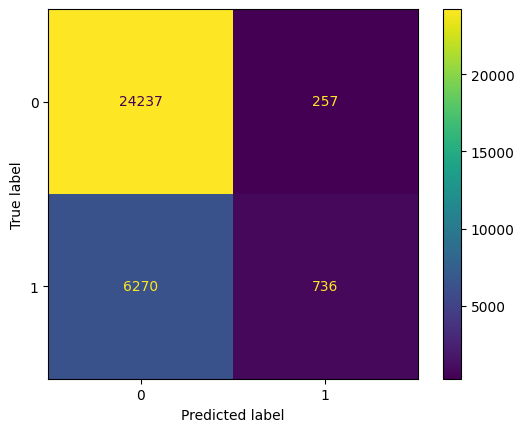

In [ ]:
evaluate_binary_classification(y_train, train["my_predict"] > 0.3)

Confusion Matrix:
[[20367  4127]
 [ 4086  2920]]

Accuracy : 0.7393
Precision: 0.4144
Recall   : 0.4168


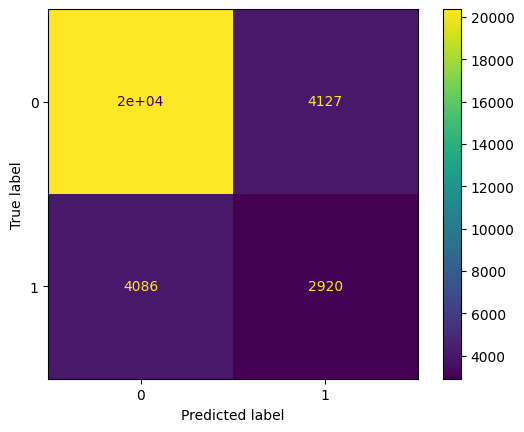

In [ ]:
evaluate_binary_classification(y_train, train["sk_predict"] > 0.3)

Confusion Matrix:
[[10401   105]
 [ 2682   312]]

Accuracy : 0.7936
Precision: 0.7482
Recall   : 0.1042


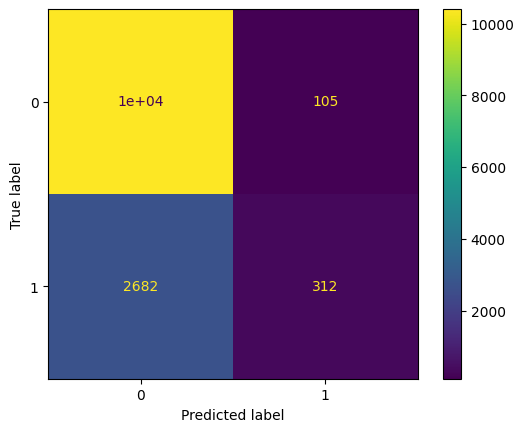

In [ ]:
evaluate_binary_classification(y_test, test["my_predict"] > 0.4)

Confusion Matrix:
[[10473    33]
 [ 2813   181]]

Accuracy : 0.7892
Precision: 0.8458
Recall   : 0.0605


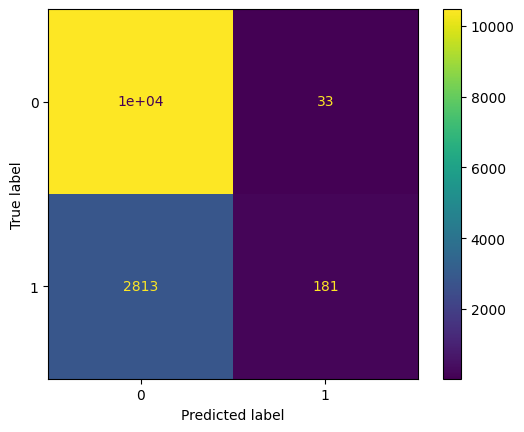

In [ ]:
evaluate_binary_classification(y_test, test["sk_predict"] > 0.4)

Заметно улучшение моделей по сравнению с использованием одного параметра.

Применим нормализацию на данные

In [ ]:
sk_lr.coef_

array([[-1.19539208e-04, -1.70645897e-10, -1.67033863e-05,
         3.38132967e-09]])

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[-0.28860483,  1.11144537, -0.70803213, -1.66607522],
       [ 0.44238884,  1.11144537,  0.00717534,  1.07809226],
       [-0.11079556, -0.89972933, -0.81011444,  1.07809226],
       ...,
       [-0.44665752,  1.11144537,  0.46299157,  1.07809226],
       [ 0.87703372,  1.11144537, -0.49884311, -1.66607522],
       [-0.0515258 , -0.89972933,  2.01235913,  1.07809226]])

In [ ]:
my_lr = MyLogisticRegression()
sk_lr = LogisticRegression()

my_lr.fit(X_train, y_train, 48)
sk_lr.fit(X_train, y_train)

0 : 0.8429538773422374
1 : 0.6044066870584908
2 : 0.5408373475014023
3 : 0.5225009247016258
4 : 0.5150005137207241
5 : 0.5110514194026075
6 : 0.5086166473813909
7 : 0.5069788377351323
8 : 0.5058291353246814
9 : 0.5049861910057506
10 : 0.5043655964482193
11 : 0.5038974272705968
12 : 0.503544210914198
13 : 0.5032693230079383
14 : 0.5030623081735321
15 : 0.5029002108048911
16 : 0.5027734004798129
17 : 0.5026749976013011
18 : 0.5025960845354304
19 : 0.5025356188162101
20 : 0.5024871579443146
21 : 0.5024490067377794
22 : 0.5024188794830924
23 : 0.5023947900717178
24 : 0.5023759759117611
25 : 0.5023614865690413
26 : 0.5023486934603907
27 : 0.5023391883165123
28 : 0.5023314829427661
29 : 0.5023256767939613
30 : 0.5023201334397752
31 : 0.5023164965887292
32 : 0.5023137904021513
33 : 0.5023111225404122
34 : 0.5023088025529358
35 : 0.5023071885922873
36 : 0.5023060627375673
37 : 0.502304994415421
38 : 0.5023040879637656
39 : 0.50230368212087
40 : 0.5023033116173776
41 : 0.5023032989258946
42 : 0

LogisticRegression()

In [ ]:
train["my_predict"] = my_lr.predict_proba(X_train)
test["my_predict"] = my_lr.predict_proba(X_test)
train["sk_predict"] = sk_lr.predict_proba(X_train)[:, 1]
test["sk_predict"] = sk_lr.predict_proba(X_test)[:, 1]

Confusion Matrix:
[[20331  4163]
 [ 4064  2942]]

Accuracy : 0.7388
Precision: 0.4141
Recall   : 0.4199


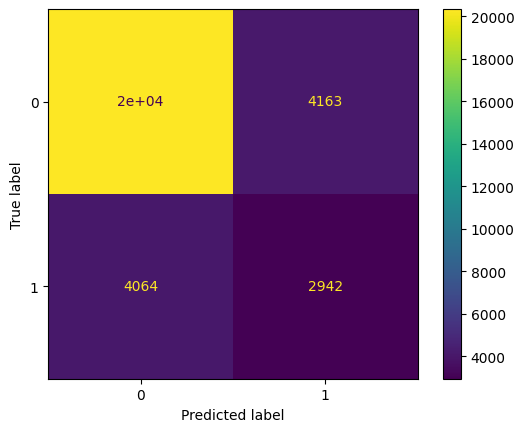

In [ ]:
evaluate_binary_classification(y_train, train["my_predict"] > 0.3)

In [ ]:
sk_lr.coef_

array([[-0.01739459, -0.00878974, -1.04025787,  0.01490278]])

Видно, что при нормировке данных, значения коэффициентов значительно увеличились.

### Создавние интергальной модели

In [ ]:
client_features = [x for x in df.columns if x.startswith("person")]
product_features = [x for x in df.columns if x.startswith("loan")]
cred_hist_features = [
    x for x in df.columns if x not in (client_features + product_features)
]

In [ ]:
from sklearn.model_selection import train_test_split

sc_cl = StandardScaler()
sc_pr = StandardScaler()
sc_cr = StandardScaler()

train, test = train_test_split(df_woe, test_size=0.3)

X_client_train = train[client_features]
X_client_test = test[client_features]

sc_cl.fit(X_client_train)
X_client_train = sc_cl.transform(X_client_train)
X_client_test = sc_cl.transform(X_client_test)

X_prod_train = train[product_features].drop(TARGET, axis=1)
X_prod_test = test[product_features].drop(TARGET, axis=1)

sc_cl.fit(X_prod_train)
X_prod_train = sc_cl.transform(X_prod_train)
X_prod_test = sc_cl.transform(X_prod_test)

X_cred_train = train[cred_hist_features]
X_cred_test = test[cred_hist_features]

sc_cl.fit(X_cred_train)
X_cred_train = sc_cl.transform(X_cred_train)
X_cred_test = sc_cl.transform(X_cred_test)

y_train = train[TARGET]
y_test = test[TARGET]

In [ ]:
client_lr = LogisticRegression()
prod_lr = LogisticRegression()
cred_lr = LogisticRegression()

client_lr.fit(X_client_train, y_train)
prod_lr.fit(X_prod_train, y_train)
cred_lr.fit(X_cred_train, y_train)

LogisticRegression()

In [ ]:
client_pred_train = client_lr.predict_proba(X_client_train)[:, 1]
prod_pred_train = prod_lr.predict_proba(X_prod_train)[:, 1]
cred_pred_train = cred_lr.predict_proba(X_cred_train)[:, 1]

client_pred_test = client_lr.predict_proba(X_client_test)[:, 1]
prod_pred_test = prod_lr.predict_proba(X_prod_test)[:, 1]
cred_pred_test = cred_lr.predict_proba(X_cred_test)[:, 1]

In [ ]:
X_meta_train = np.vstack((client_pred_train, prod_pred_train, cred_pred_train)).T
X_meta_test = np.vstack((client_pred_test, prod_pred_test, cred_pred_test)).T

In [ ]:
meta_model = LogisticRegression()
meta_model.fit(X_meta_train, y_train)

LogisticRegression()

In [ ]:
final_preds = meta_model.predict_proba(X_meta_test)[:, 1]
final_preds2 = meta_model.predict_proba(X_meta_train)[:, 1]

Confusion Matrix:
[[9931  560]
 [ 898 2111]]

Accuracy : 0.8920
Precision: 0.7903
Recall   : 0.7016
Confusion Matrix:
[[23205  1304]
 [ 2186  4805]]

Accuracy : 0.8892
Precision: 0.7865
Recall   : 0.6873


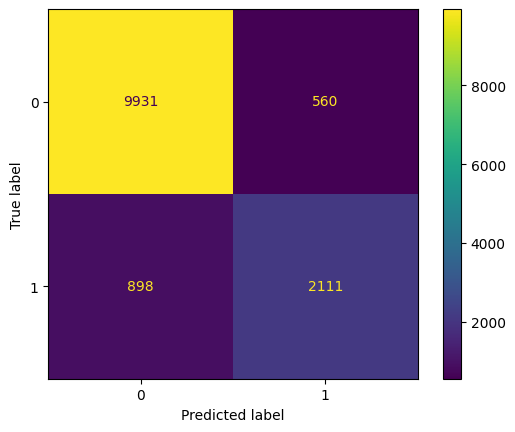

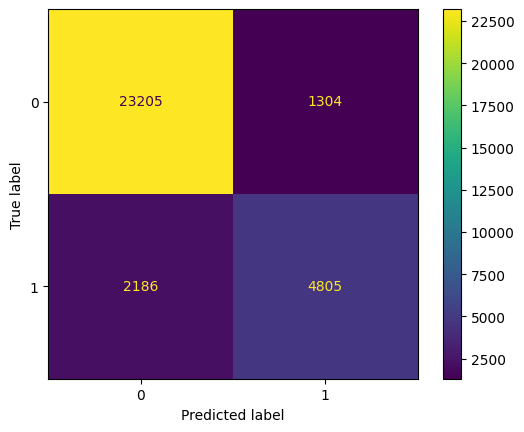

In [ ]:
evaluate_binary_classification(y_test, final_preds > 0.5)
evaluate_binary_classification(y_train, final_preds2 > 0.5)

Модель достаточно хорошо предсказывает

Сравним с обычной логистической регрессией по всему факторному пространству

In [ ]:
sc = StandardScaler()

sc.fit(train.drop(TARGET, axis=1))
X_train = sc.transform(train.drop(TARGET, axis=1))
X_test = sc.transform(test.drop(TARGET, axis=1))
y_train = train[TARGET]
y_test = test[TARGET]

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
train_preds = lr.predict(X_train)
test_preds = lr.predict(X_test)

Confusion Matrix:
[[22973  1523]
 [ 1762  5242]]

Accuracy : 0.8957
Precision: 0.7749
Recall   : 0.7484


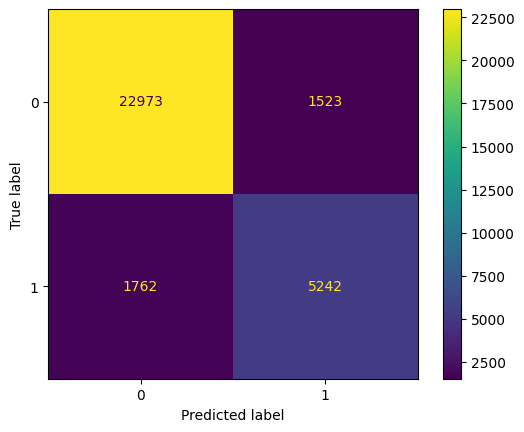

In [ ]:
evaluate_binary_classification(y_train, train_preds)

Confusion Matrix:
[[9839  665]
 [ 756 2240]]

Accuracy : 0.8947
Precision: 0.7711
Recall   : 0.7477


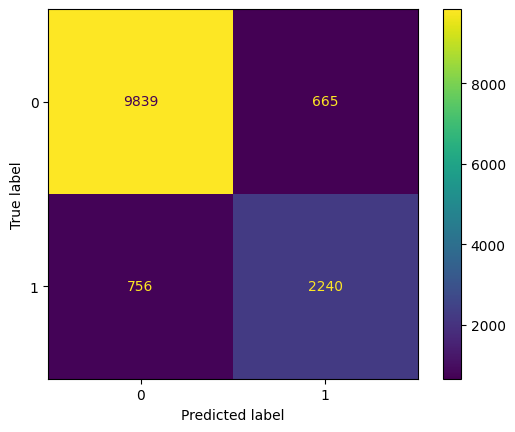

In [ ]:
evaluate_binary_classification(y_test, test_preds)

Как видно, ансамблевые модели показывают лучшие показателели.

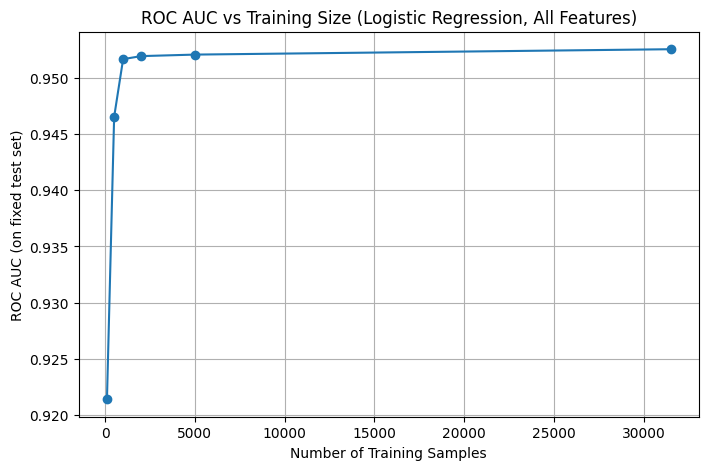

In [ ]:
from sklearn.utils import resample
import matplotlib.pyplot as plt


train_sizes = [100, 500, 1000, 2000, 5000, len(y_train)]
auc_scores = []

for size in train_sizes:
    X_sub, y_sub = resample(
        X_train, y_train, n_samples=size, random_state=42, stratify=y_train
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_sub, y_sub)

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)

    auc_scores.append(auc)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, auc_scores, marker="o", linestyle="-")
plt.title("ROC AUC vs Training Size (Logistic Regression, All Features)")
plt.xlabel("Number of Training Samples")
plt.ylabel("ROC AUC (on fixed test set)")
plt.grid(True)
plt.show()